In [57]:
#https://opendata.cityofnewyork.us/
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
#https://data.cityofnewyork.us/Public-Safety/NYPD-Arrest-Data-Year-to-Date-/uip8-fykc/about_data

#another way
#df = pd.read_csv('filename'.csv')
#download same file into the same location

Saving NYPD_Arrest_Data_(Year_to_Date)_20260407.csv to NYPD_Arrest_Data_(Year_to_Date)_20260407 (1).csv


In [3]:
#tasks
#the goal of this project is to analyze nypd arrest data
#pick any zip code/neighborhood/district in this dataset as an initial comparison point
#pick a feature/measure/column
#compare above entity to any other (different) entity
#you only need to do one additional comparison point (but you’re welcome to do more comparisons if you feel compelled to do so)
#the analysis should include some descriptive statistics
#the analysis should include one cleaning task (or more)
#the analysis should include one visualization (or more)
#the analysis should include a brief conclusion statement that includes a discussion on bias (no more than four sentences)

In [4]:
#https://data.cityofnewyork.us/api/v3/views/uip8-fykc/query.csv
#arrest data YTD as of 4/7/2026 (date I saved csv file)

df_arrests = pd.read_csv("NYPD_Arrest_Data_(Year_to_Date)_20260407.csv")

In [5]:
#to show the first 5 rows
df_arrests.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [6]:
#show the last 5 rows
df_arrests.tail()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
278948,318159497,12/30/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,K,70,0,(null),(null),BLACK,999359,169275,40.631293,-73.945566,POINT (-73.945566 40.631293)
278949,318206208,12/31/2025,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,25,0,25-44,F,BLACK,1000581,231070,40.800904,-73.941012,POINT (-73.941012 40.800904)
278950,318144122,12/30/2025,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,110,0,18-24,F,BLACK,1024817,213376,40.752260,-73.853581,POINT (-73.853581 40.75226)
278951,318209021,12/31/2025,779,"PUBLIC ADMINISTRATION,UNCLASSI",126.0,MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,109,0,25-44,M,BLACK HISPANIC,1040185,217007,40.762143,-73.798083,POINT (-73.798083 40.762143)
278952,318207879,12/31/2025,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,S,120,0,(null),(null),WHITE HISPANIC,964114,166065,40.622464,-74.072535,POINT (-74.07253516 40.62246362)


In [7]:
#showing 10 random rows
df_arrests.sample(10)

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
207333,313241933,09/20/2025,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,S,120,0,18-24,M,WHITE HISPANIC,962873,174172,40.644721,-74.077033,POINT (-74.0770327198983 40.6447209438691)
49736,301890914,03/01/2025,779,"PUBLIC ADMINISTRATION,UNCLASSI",126.0,MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,100,0,(null),(null),BLACK,1035353,152906,40.586230,-73.816012,POINT (-73.816012 40.58623)
121594,307825415,06/10/2025,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,B,47,0,25-44,F,BLACK,1027500,260415,40.881358,-73.843595,POINT (-73.843595 40.881358)
31445,300266414,01/30/2025,273,"TAMPERING 1,CRIMINAL",121.0,CRIMINAL MISCHIEF & RELATED OF,PL 1452000,F,M,18,1,45-64,M,BLACK HISPANIC,987618,219846,40.770111,-73.987840,POINT (-73.98784 40.770111)
55385,303314104,03/20/2025,478,"THEFT OF SERVICES, UNCLASSIFIE",343.0,OTHER OFFENSES RELATED TO THEFT,PL 1651503,M,K,83,1,(null),(null),BLACK,1007052,193757,40.698474,-73.917769,POINT (-73.917768981221 40.6984738177025)
210597,313720081,09/30/2025,117,RECKLESS ENDANGERMENT 1,126.0,MISCELLANEOUS PENAL LAW,PL 1202500,F,S,122,0,(null),(null),ASIAN / PACIFIC ISLANDER,956579,159661,40.604875,-74.099652,POINT (-74.099652 40.604875)
273695,317510540,12/14/2025,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,67,0,45-64,F,BLACK,1003981,175117,40.647321,-73.928896,POINT (-73.928896 40.647321)
76718,304113139,04/03/2025,478,"THEFT OF SERVICES, UNCLASSIFIE",343.0,OTHER OFFENSES RELATED TO THEFT,PL 1651503,M,B,40,0,(null),(null),BLACK,1005028,234516,40.810352,-73.924942,POINT (-73.924942325642 40.8103518634571)
176281,311380208,08/18/2025,494,"STOLEN PROPERTY 2,1,POSSESSION",111.0,POSSESSION OF STOLEN PROPERTY,PL 1655000,F,K,71,0,(null),(null),WHITE HISPANIC,998742,181235,40.664121,-73.947765,POINT (-73.9477648403751 40.664121282631)
118130,308213653,06/17/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,M,34,0,25-44,F,WHITE HISPANIC,1002413,248809,40.849589,-73.934349,POINT (-73.934349 40.849589)


In [8]:
#list out columns
df_arrests.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [9]:
#finding info to see data types and missing values
#can already see that KY_CD and LAW_CAT_CD is missing values since it doesn't equal 278953.
df_arrests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

In [10]:
#looking at columns through a summary statistics overview
#has a count for numeric columns, most freq value (top) row and how many times
  #that value pops up (freq) for non-numeric columns, has the standar deviation and the distributions and skew/percentiles

#assaults are the biggest crimes occurring around May a week before mother's day
df_arrests.describe(include='all')

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
count,2.789530e+05,278953,278953.000000,278953,278930.000000,278953,278953,277479,278953,278953.000000,278953.000000,278953,278953,278953,2.789530e+05,278953.000000,278953.000000,278953.000000,278953
unique,NaN,365,NaN,262,NaN,63,1148,5,5,NaN,NaN,6,3,7,NaN,NaN,NaN,NaN,39053
top,NaN,05/07/2025,NaN,ASSAULT 3,NaN,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,NaN,NaN,(null),(null),BLACK,NaN,NaN,NaN,NaN,POINT (-73.9945368920152 40.7535327012632)
freq,NaN,1199,NaN,29405,NaN,39728,28812,160986,79882,NaN,NaN,147237,147237,134262,NaN,NaN,NaN,NaN,2081
mean,3.085697e+08,NaN,443.764512,NaN,258.919467,NaN,NaN,NaN,NaN,63.047255,0.932132,NaN,NaN,NaN,1.005315e+06,207515.629314,40.736243,-73.923782,NaN
std,5.664370e+06,NaN,274.632619,NaN,148.433045,NaN,NaN,NaN,NaN,34.798913,6.820188,NaN,NaN,NaN,2.235094e+04,29840.507845,0.081812,0.076414,NaN
min,2.987043e+08,NaN,12.000000,NaN,101.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,-7.400000e+01,40.000000,40.500390,-74.252488,NaN
25%,3.038432e+08,NaN,157.000000,NaN,117.000000,NaN,NaN,NaN,NaN,40.000000,0.000000,NaN,NaN,NaN,9.906010e+05,184932.000000,40.674210,-73.977117,NaN
50%,3.086091e+08,NaN,439.000000,NaN,341.000000,NaN,NaN,NaN,NaN,62.000000,0.000000,NaN,NaN,NaN,1.005028e+06,206168.000000,40.732551,-73.924942,NaN
75%,3.135027e+08,NaN,724.000000,NaN,344.000000,NaN,NaN,NaN,NaN,100.000000,0.000000,NaN,NaN,NaN,1.017273e+06,235780.000000,40.813808,-73.880601,NaN


In [11]:
#looking at the dataset made me interested in comparing the seasonal patterns/time trends with age groups
#i decided on ages 18-24 and the next group above just because between those two are the largest arrest groups (I predicted this but will look at the data)
  #18-24 = from when person is considered an adult to 24
  #25-44 = this age range ends at 44 or just about what's considered middle age?
df_arrests['AGE_GROUP'].value_counts()

#there are many many nulls - I think I will just drop them

,count
AGE_GROUP,
(null),147237
25-44,77063
45-64,29326
18-24,17786
<18,4766
65+,2775


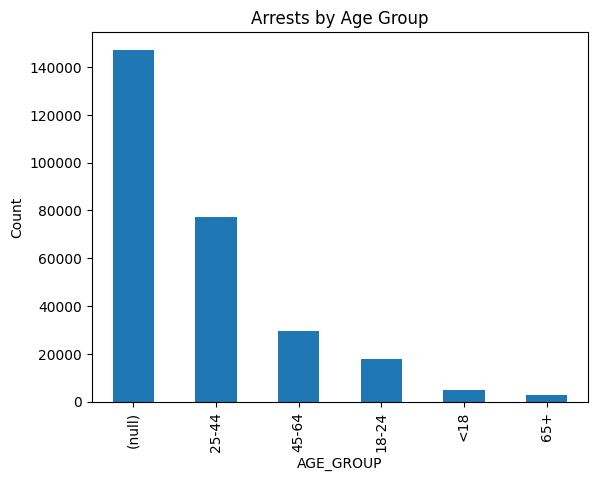

In [12]:
#make chart to see age groups
df_arrests['AGE_GROUP'].value_counts().plot(kind='bar')
plt.title("Arrests by Age Group")
plt.ylabel("Count")
plt.show()

In [35]:
#cleaning data with the null values in the age groups
#null is a string
df_arrests['AGE_GROUP'].value_counts(dropna=False)

,count
AGE_GROUP,
Unknown,147237
25-44,77063
45-64,29326
18-24,17786
<18,4766
65+,2775


In [34]:
df_arrests['AGE_GROUP'] = (
    df_arrests['AGE_GROUP']
    .replace(['UNKNOWN', '(null)', 'Null', 'NULL'], 'Unknown')
    .fillna('Unknown')
)

In [37]:
#changed all the nulls (see above code) to "unknown" and not a string
#verifying that the cleaning worked
df_arrests['AGE_GROUP'].value_counts(dropna=False)

,count
AGE_GROUP,
Unknown,147237
25-44,77063
45-64,29326
18-24,17786
<18,4766
65+,2775


In [14]:
#since I decided on time trends, I'll convert the dates from strings to actual usable dates
df_arrests['ARREST_DATE'] = pd.to_datetime(df_arrests['ARREST_DATE'])
df_arrests['YEAR'] = df_arrests['ARREST_DATE'].dt.year
df_arrests['MONTH'] = df_arrests['ARREST_DATE'].dt.to_period('M')

In [19]:
age_groups = ['18-24', '25-44']

df_filtered = df_arrests[df_arrests['AGE_GROUP'].isin(age_groups)]

yearly_trends = (
    df_filtered.groupby(['MONTH', 'AGE_GROUP'])
    .size()
    .reset_index(name='ARREST_COUNT')
)

yearly_trends.head()

,MONTH,AGE_GROUP,ARREST_COUNT
0,2025-01,18-24,1027
1,2025-01,25-44,4819
2,2025-02,18-24,908
3,2025-02,25-44,4637
4,2025-03,18-24,1124


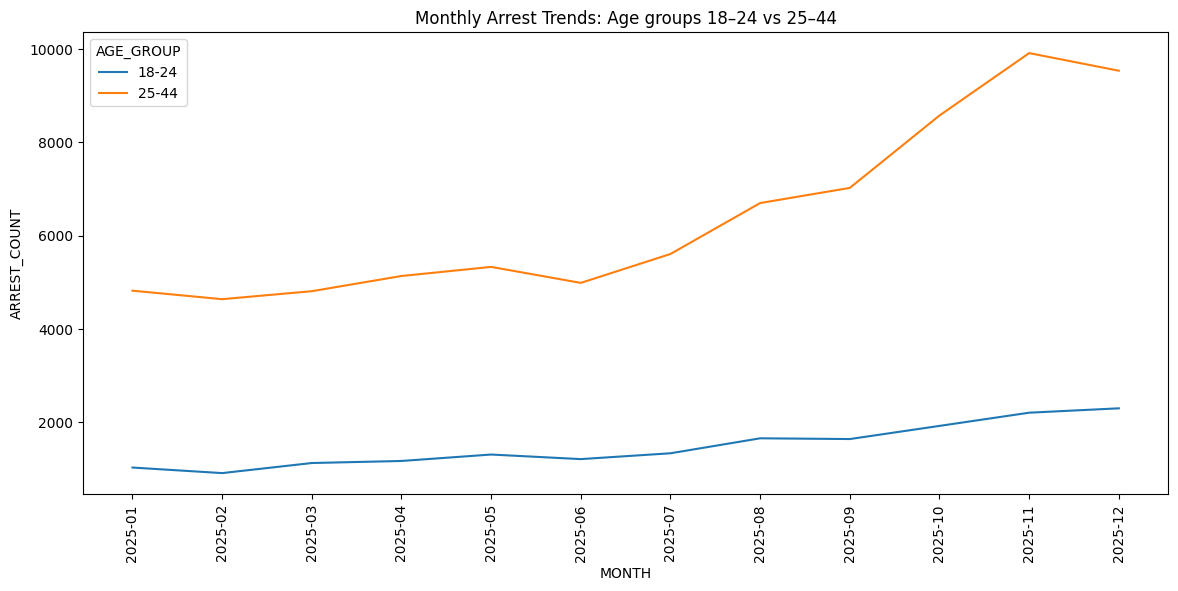

In [22]:
monthly_trends = (
    df_filtered.groupby(['MONTH', 'AGE_GROUP'])
    .size()
    .reset_index(name='ARREST_COUNT')
)

monthly_trends['MONTH'] = monthly_trends['MONTH'].astype(str)

plt.figure(figsize=(14,6))
sns.lineplot(
    data=monthly_trends,
    x='MONTH',
    y='ARREST_COUNT',
    hue='AGE_GROUP'
)

plt.xticks(rotation=90)
plt.title("Monthly Arrest Trends: Age groups 18–24 vs 25–44")
plt.show()

In [38]:
#picking a precinct and listing the top 10 with most arrests
df_arrests['ARREST_PRECINCT'].value_counts().head(10)

,count
ARREST_PRECINCT,
14,10364
40,9244
75,9039
44,7863
103,7803
46,7230
120,6264
73,6050
47,5942


In [41]:
#picked the top 2 precincts with the most arrests
p14 = df_arrests[df_arrests['ARREST_PRECINCT'] == 14]
p40 = df_arrests[df_arrests['ARREST_PRECINCT'] == 40]

In [44]:
#comparing both precincts' arrest counts by age group
p14['AGE_GROUP'].value_counts()

,count
AGE_GROUP,
Unknown,6045
25-44,2465
45-64,1119
18-24,503
<18,119
65+,113


In [45]:
p40['AGE_GROUP'].value_counts()

,count
AGE_GROUP,
Unknown,6066
25-44,1781
45-64,720
18-24,471
<18,150
65+,56


In [80]:
precincts = [14, 40]
age_groups = ['18-24', '25-44']

In [81]:
#error - found out i have to convert the month back into a string for seaborn
df_grouped['MONTH'] = df_grouped['MONTH'].astype(str)

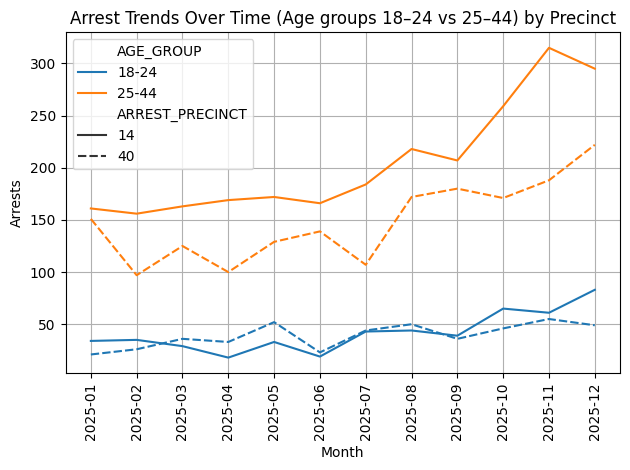

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=df_grouped,
    x='MONTH',
    y='ARREST_COUNT',
    hue='AGE_GROUP',
    style='ARREST_PRECINCT'
)

plt.xticks(rotation=90)
plt.title("Arrest Trends Over Time (Age groups 18–24 vs 25–44) by Precinct")
plt.ylabel("Arrests")
plt.xlabel("Month")
plt.grid(True)
plt.tight_layout()
plt.show()

Conclusion: In 2025, Precinct 14 had a sharper spike in arrests of age groups 25-44 from June to December but both precincts 14 and 40 had increased illegal activities during that half of the year. I attribute it to the holiday season/summer break and warmer weather. Also, the previous mayor was on his way out so I think his police policies might have increased around that time.

Age groups 18-24 had less criminal activity across both precincts but had more spikes, which makes me think younger people are affected by seasons and local events/holidays/police activity.

Precinct 14 - MIDTOWN (Times Sq, Grant Central, etc);
Precinct 40 - SOUTH BRONX